In [1]:
import qsharp
import random
import json
from diskcache import Cache

cache = Cache("~/quant-arith-cache/")
qsharp.init(project_root="../")

@cache.memoize()
def estimate_resources_multiply(op, n):
    est = qsharp.estimate(f"EstimateUtils.RunMultiply({n},{op})")
    return json.dumps(est)    

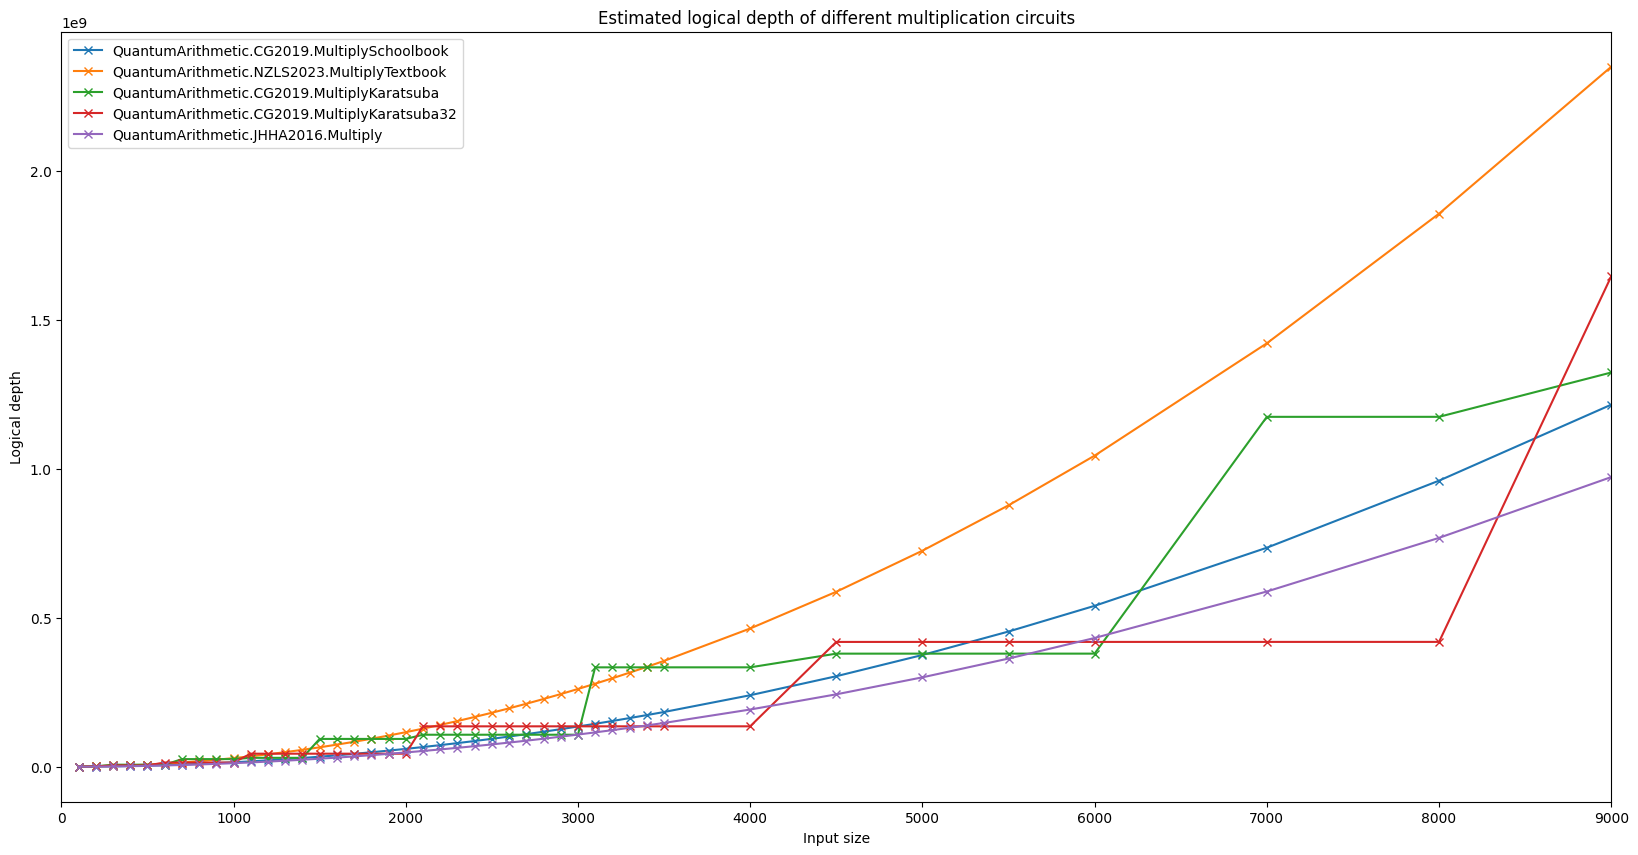

In [2]:
ops = [
  "QuantumArithmetic.CG2019.MultiplySchoolbook",
  "QuantumArithmetic.NZLS2023.MultiplyTextbook",
  "QuantumArithmetic.CG2019.MultiplyKaratsuba",
  "QuantumArithmetic.CG2019.MultiplyKaratsuba32",  
  "QuantumArithmetic.JHHA2016.Multiply",  
]

depth_chart = {op: [] for op in ops}
runtime_chart = {op: [] for op in ops}
n_range = list(range(100, 3600, 100)) + [4000, 4500, 5000, 5500, 6000, 7000, 8000, 9000]

import time

for n in n_range:
    for op in ops:
        t0=time.time()
        estimates = json.loads(estimate_resources_multiply(op, n))
        #print(n, op, time.time()-t0, flush=True)
        runtime_chart[op].append(estimates['physicalCounts']['runtime'])
        depth_chart[op].append(estimates['physicalCounts']['breakdown']['logicalDepth'])
    
    
from matplotlib import pyplot as plt

plt.figure(figsize=(20, 10))
for op in ops:
    plt.plot(n_range, depth_chart[op], label=op, marker='x')
plt.xlim([0,max(n_range)])
plt.legend()
plt.xlabel('Input size')
plt.ylabel('Logical depth')
plt.title('Estimated logical depth of different multiplication circuits')
plt.show()